In [16]:
%load_ext autoreload
%autoreload 2

import numpy as np
import matplotlib.pyplot as plt
from linear_regression import LinearRegressor
from mpl_toolkits.mplot3d import Axes3D

The autoreload extension is already loaded. To reload it, use:
  %reload_ext autoreload


In [17]:
def load_data():
    X = np.loadtxt("../data/Q1/linearX.csv", delimiter=',',dtype=float)
    if X.ndim == 1:
        X = X[:, np.newaxis]
    y = np.loadtxt("../data/Q1/linearY.csv", dtype=float)

    return X, y


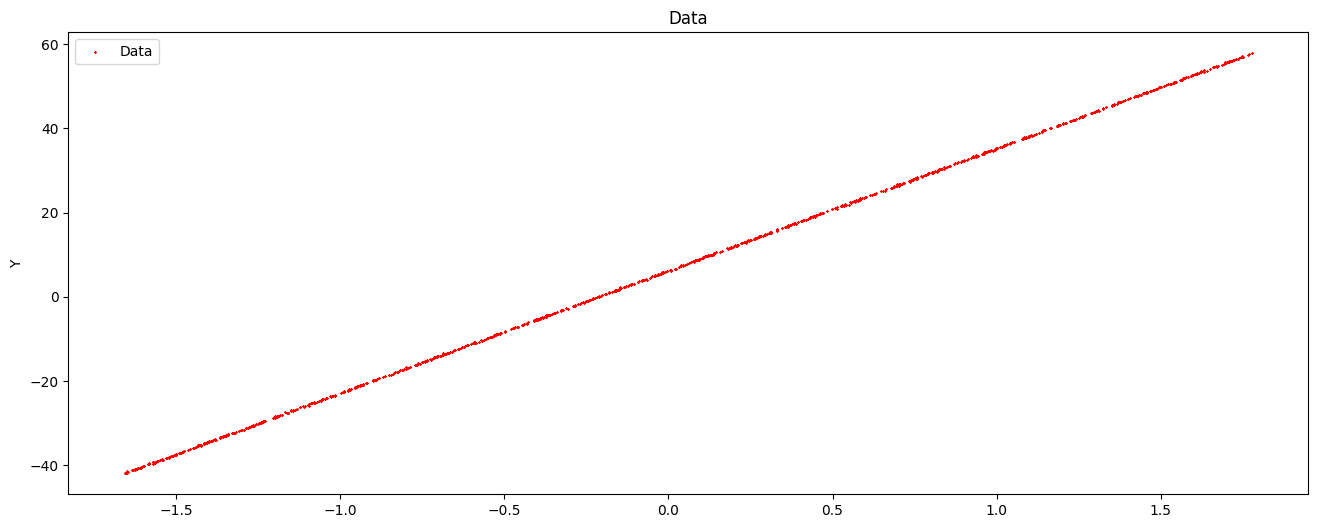

In [18]:
def plot_data(X, y):
    plt.figure(figsize=(16, 6))

    plt.scatter(X, y, c='r', marker='x',s=1)
    plt.xlabel('')
    plt.ylabel('Y')
    plt.title('Data')
    plt.legend(['Data'])
    plt.show()
X,y = load_data()
plot_data(X, y)

In [19]:
LR = LinearRegressor()

X, y = load_data()

print(X.shape, y.shape)
params_list = LR.fit(X, y,1.0)

print("Final Theta :" , LR.theta)

#accuracy   
y_pred = LR.predict(X)

def mse(y, y_pred):
    return np.mean((y - y_pred)**2)

print("Mean Squared Error: ", mse(y, y_pred))
print("Number of iterations: ", LR.iterations )




(1000, 1) (1000,)
Final Theta : [ 6.21867801 29.06475515]
Mean Squared Error:  0.009749890551957964
Number of iterations:  4


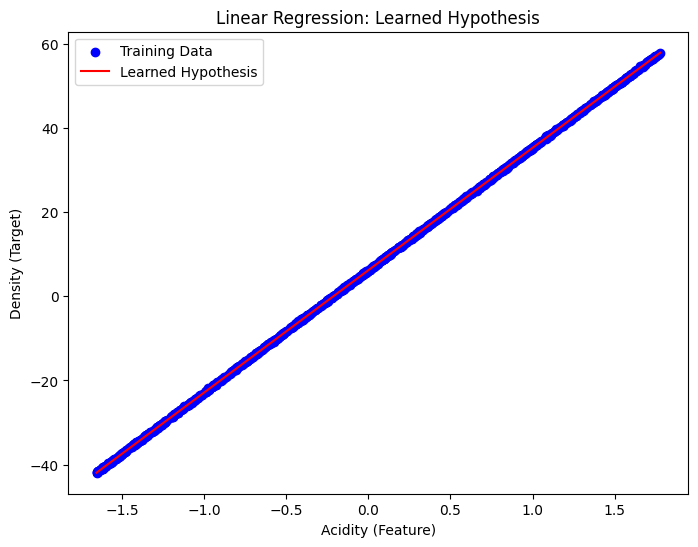

In [20]:
theta = LR.theta
x_range = np.linspace(min(X), max(X), 100)
y_pred = theta[0] + theta[1] * x_range  


plt.figure(figsize=(8, 6))
plt.scatter(X, y, color='blue', label="Training Data")  
plt.plot(x_range, y_pred, color='red', label="Learned Hypothesis")
plt.xlabel("Acidity (Feature)")
plt.ylabel("Density (Target)")
plt.title("Linear Regression: Learned Hypothesis")
plt.legend()
plt.show()

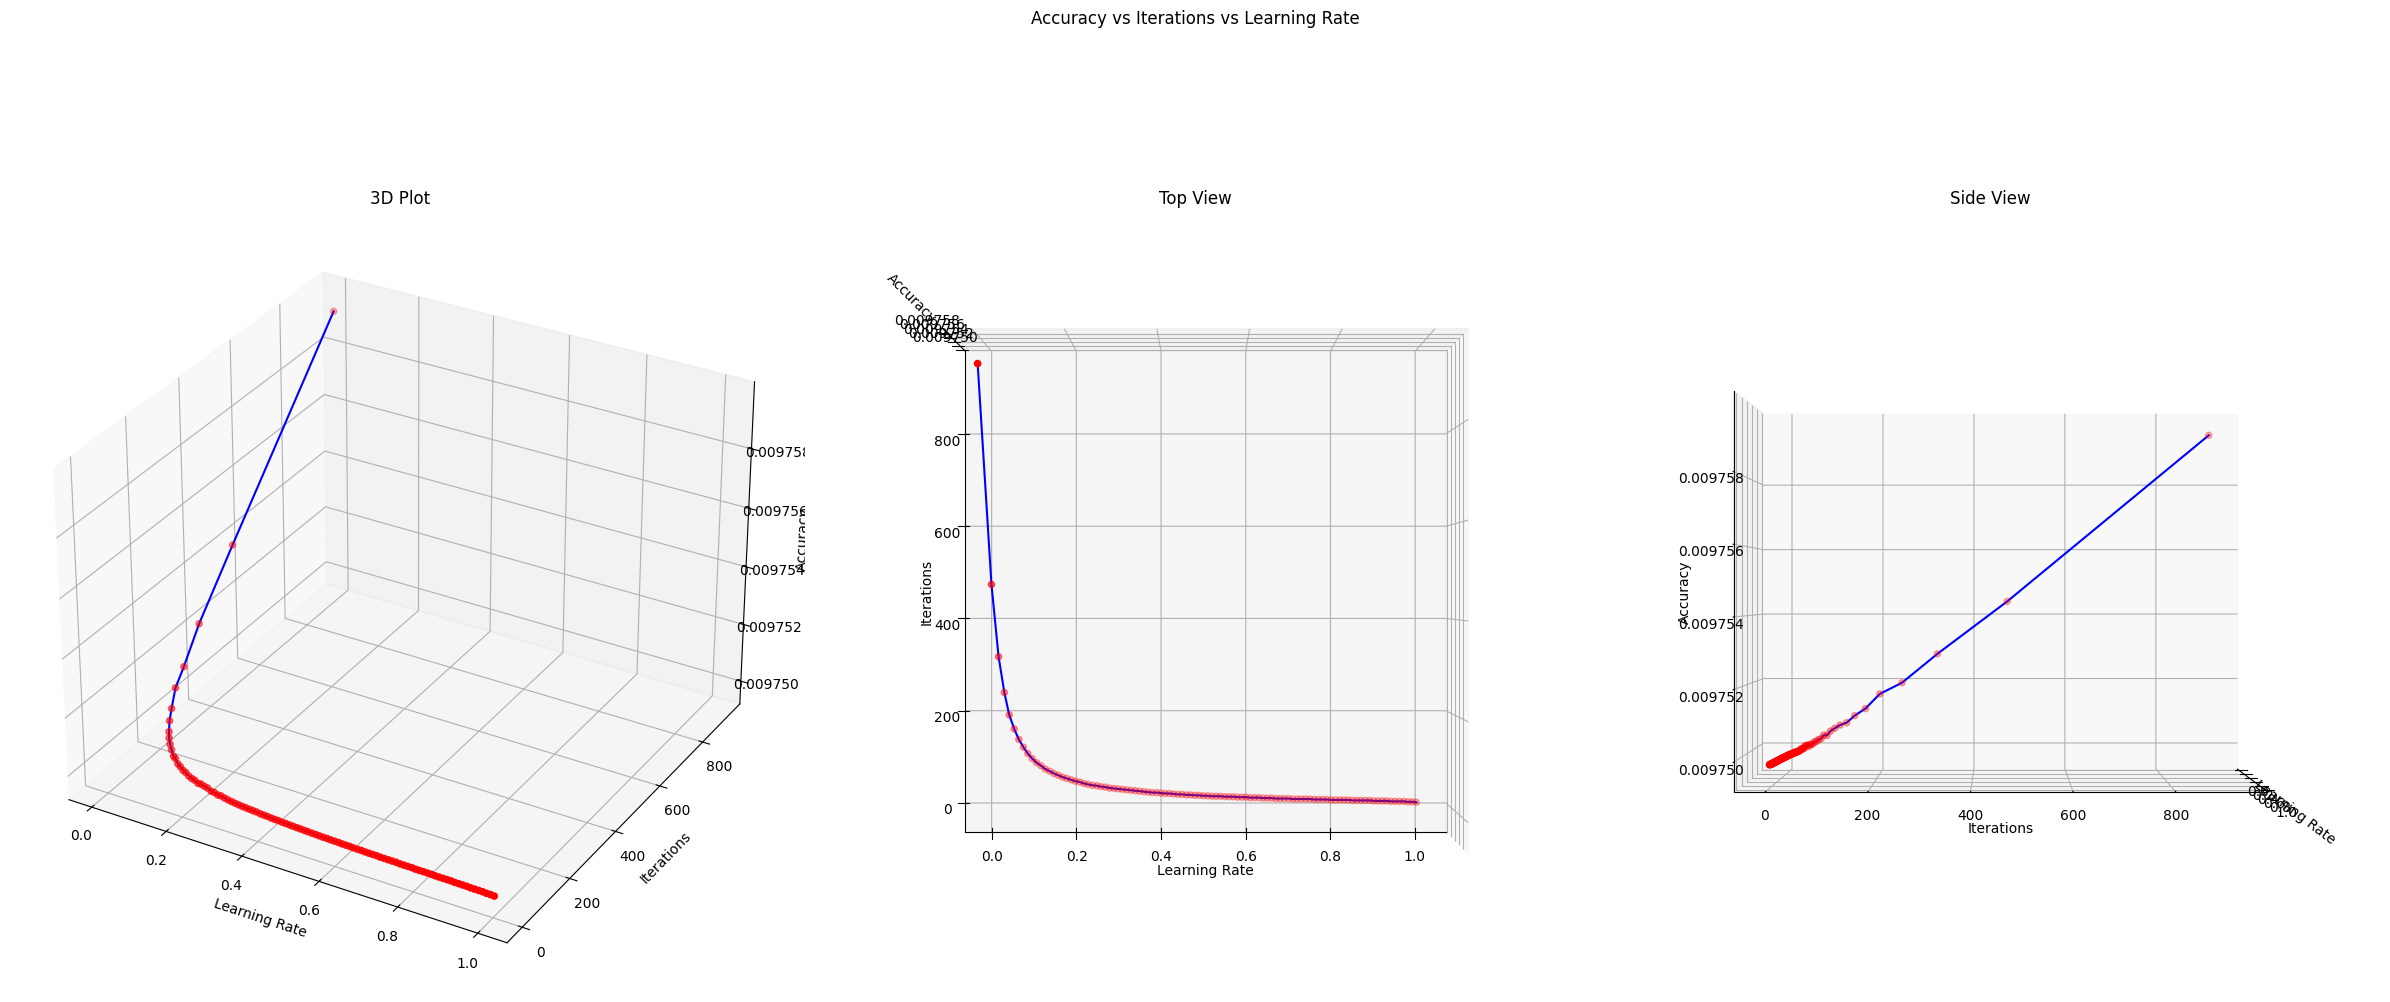

In [21]:
def accuracy(y_true, y_pred):
    return np.mean((y - y_pred)**2)


Accuracy_per_learning_rate = []
Iterations_per_learning_rate = []

for learning_rate in np.linspace(0.01, 1, 100):
    LR = LinearRegressor()
    LR.fit(X, y, learning_rate)
    y_pred = LR.predict(X)
    Accuracy_per_learning_rate.append(accuracy(y, y_pred))
    Iterations_per_learning_rate.append(LR.iterations)

def plot3D_accuracy_iterations_learning_rate(learning_rate, accuracy, iterations):
    fig = plt.figure(figsize=(24, 12)) 
    
    # Main 3D plot
    ax = fig.add_subplot(131, projection='3d')
    ax.scatter(learning_rate, iterations, accuracy, s=20, color='red')
    ax.plot(learning_rate, iterations, accuracy, color='blue')
    ax.set_xlabel('Learning Rate')
    ax.set_ylabel('Iterations')
    ax.set_zlabel('Accuracy')
    ax.set_title('3D Plot')
    
    # Top view
    ax_top = fig.add_subplot(132, projection='3d')
    ax_top.scatter(learning_rate, iterations, accuracy, s=20, color='red')
    ax_top.plot(learning_rate, iterations, accuracy, color='blue')
    ax_top.set_xlabel('Learning Rate')
    ax_top.set_ylabel('Iterations')
    ax_top.set_zlabel('Accuracy')
    ax_top.set_title('Top View')
    ax_top.view_init(elev=90, azim=-90)  
    
    # Side view
    ax_side = fig.add_subplot(133, projection='3d')
    ax_side.scatter(learning_rate, iterations, accuracy, s=20, color='red')
    ax_side.plot(learning_rate, iterations, accuracy, color='blue')
    ax_side.set_xlabel('Learning Rate')
    ax_side.set_ylabel('Iterations')
    ax_side.set_zlabel('Accuracy')
    ax_side.set_title('Side View')
    ax_side.view_init(elev=0, azim=0) 
    
    plt.suptitle('Accuracy vs Iterations vs Learning Rate')
    plt.tight_layout()  
    plt.show()


plot3D_accuracy_iterations_learning_rate(np.linspace(0.01, 1, 100), Accuracy_per_learning_rate, Iterations_per_learning_rate)
    